# **Lab 4 — Assessment**
## Intensity Transformations and Filtering — Spatial Domain

**Student:** Salem
**Course:** ARTI 404 — Image Processing
**Lab Outcome #2:** Write a program that implements fundamental image processing algorithms.

---

## Assessment tasks

1. **Task #1** — Using the moon image, rescale intensity values to the **3rd–80th percentile** range and plot the histogram.
2. **Task #2** — Using the moon image and `exposure.equalize_hist`, display the image and its **flattened (equalized) histogram**.
3. **Task #3** — Use the **rocket** (reference) and **chelsea** images from `skimage.data` and implement **histogram matching**.

In [14]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float, exposure

plt.rcParams['figure.dpi'] = 90

### Helper — display an image with its histogram

All three tasks need the same kind of "image on top, histogram below" plot, so we factor it out once.

In [15]:
def show_image_and_hist(image, title, bins=256, hist_range=(0, 255), figsize=(10, 6)):
    """Display a grayscale image and its intensity histogram in a 2x1 figure."""
    fig = plt.figure(figsize=figsize)

    fig.add_subplot(2, 1, 1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.title(title)

    fig.add_subplot(2, 1, 2)
    plt.hist(image.flat, bins=bins, range=hist_range, color='steelblue', edgecolor='none')
    plt.xlabel('Gray level values')
    plt.ylabel('Number of pixels')
    plt.tight_layout()
    plt.show()

---

## Task #1 — Contrast stretching to the 3rd–80th percentile

This is the same idea as the procedural example in Section 3 (which used the 2nd–98th percentile), but with a **narrower target range**: we map the intensities between $p_3$ and $p_{80}$ to fill the full $[0, 255]$ output range, and clip everything outside.

Because the upper cut-off is much lower (80% instead of 98%), a larger fraction of the bright pixels get clipped to 255 — we should expect a more aggressive contrast boost on dark/mid-tones at the cost of saturating the bright sky around the moon.

In [16]:
# 1. Load the moon image
img = data.moon()
print(f"moon: shape={img.shape}, dtype={img.dtype}, min/max={img.min()}/{img.max()}")

# 2. Compute the 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))
print(f"3rd percentile  = {p3:.2f}")
print(f"80th percentile = {p80:.2f}")

# 3. Stretch intensities in [p3, p80] to fill the full [0, 255] range
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

moon: shape=(512, 512), dtype=uint8, min/max=0/255
3rd percentile  = 87.00
80th percentile = 118.00


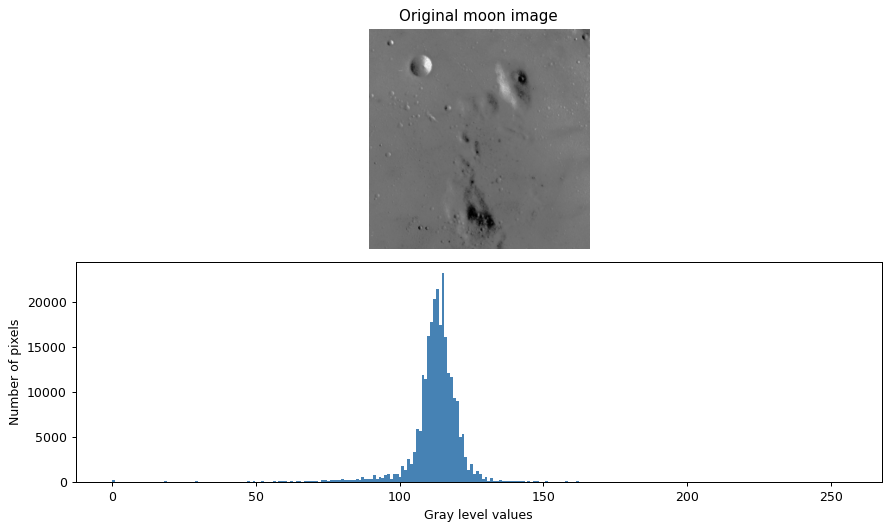

In [17]:
# Original image + histogram
show_image_and_hist(img, 'Original moon image')

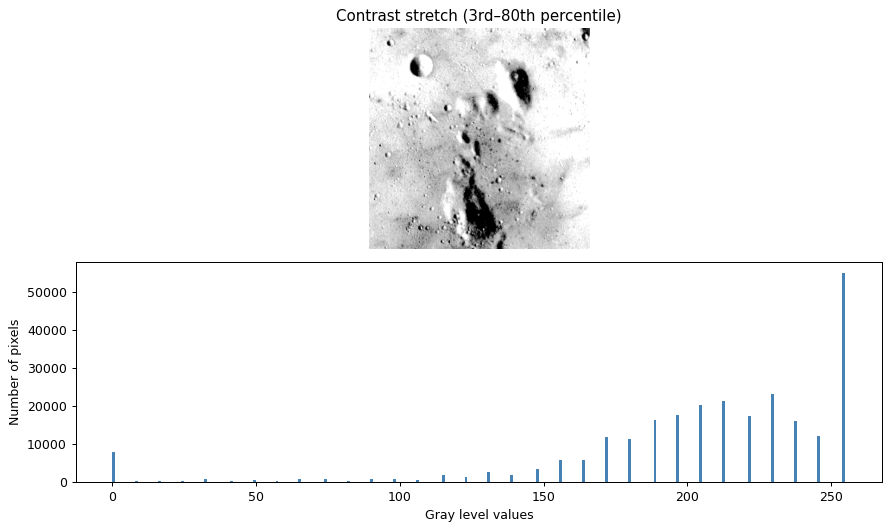

In [18]:
# Rescaled image + histogram
show_image_and_hist(img_rescale, 'Contrast stretch (3rd–80th percentile)')

**Observation.** The new histogram occupies the entire $[0, 255]$ range. The pile-up at the right edge (255) corresponds to all pixels above the 80th percentile that were clipped — visible in the image as the brightened, washed-out sky. Crater detail in the dark hemisphere is enhanced because the dark mid-tones now span a much wider portion of the intensity range.

---

## Task #2 — Histogram equalization

Histogram equalization aims to produce an output image whose intensity distribution is approximately **uniform** ("flat"). It does this by using the cumulative distribution function (CDF) of the original image as the intensity-mapping function:

$$s = T(r) = (L-1) \int_0^r p_r(w)\, dw$$

The result: dense regions of the histogram get *spread out*, and sparse regions get *compressed*. Contrast in the dominant intensity range is enhanced automatically — no parameters to tune.

Note: `exposure.equalize_hist` returns a **float image in $[0, 1]$**, so we use `hist_range=(0, 1)` for the histogram.

Equalized image: dtype=float64, min/max=0.001/1.000


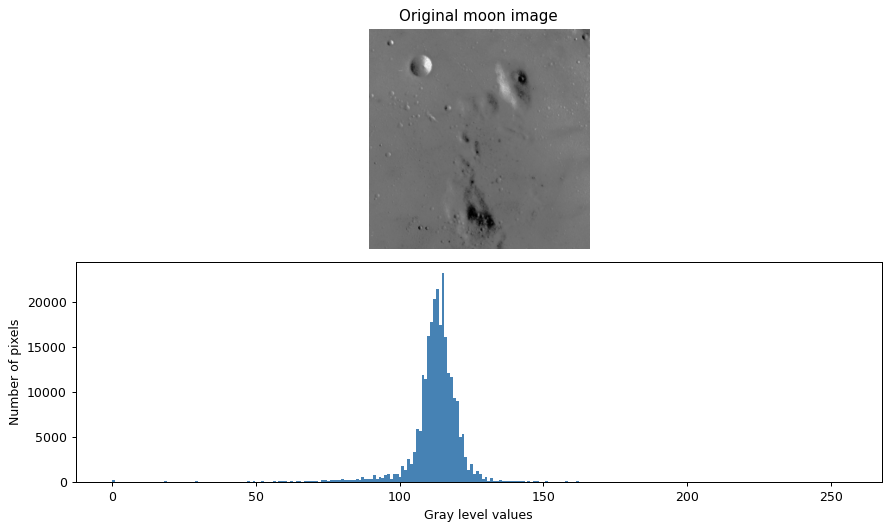

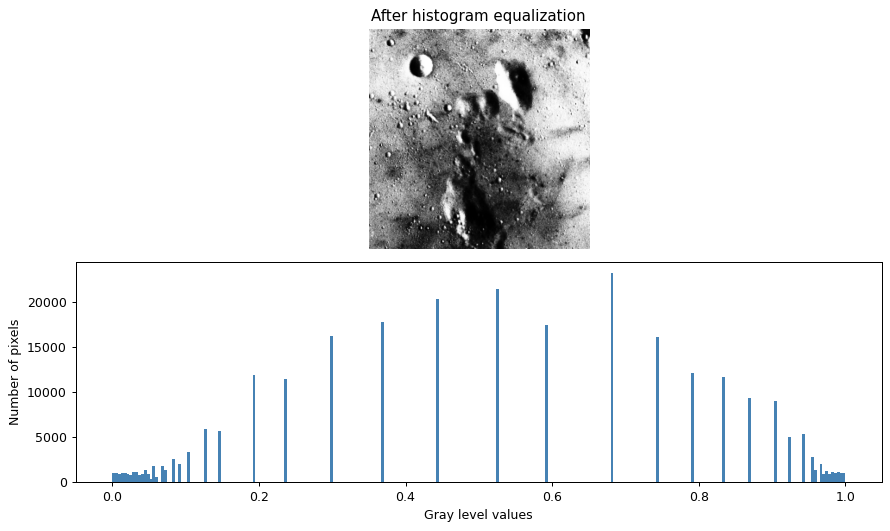

In [19]:
# 1. Apply histogram equalization (returns float image in [0, 1])
img_eq = exposure.equalize_hist(img)
print(f"Equalized image: dtype={img_eq.dtype}, min/max={img_eq.min():.3f}/{img_eq.max():.3f}")

# 2. Display side-by-side: original (uint8) vs equalized (float)
show_image_and_hist(img,    'Original moon image',        hist_range=(0, 255))
show_image_and_hist(img_eq, 'After histogram equalization', hist_range=(0, 1))

**Observation.** The equalized histogram is much closer to flat — the tall central peak of the original has been spread across the whole range. Visually, both the dark side (more crater detail) and the bright side (now-visible terminator features) gain contrast simultaneously, which is the hallmark advantage of equalization over a fixed contrast stretch.

### Bonus: comparing the three approaches side-by-side

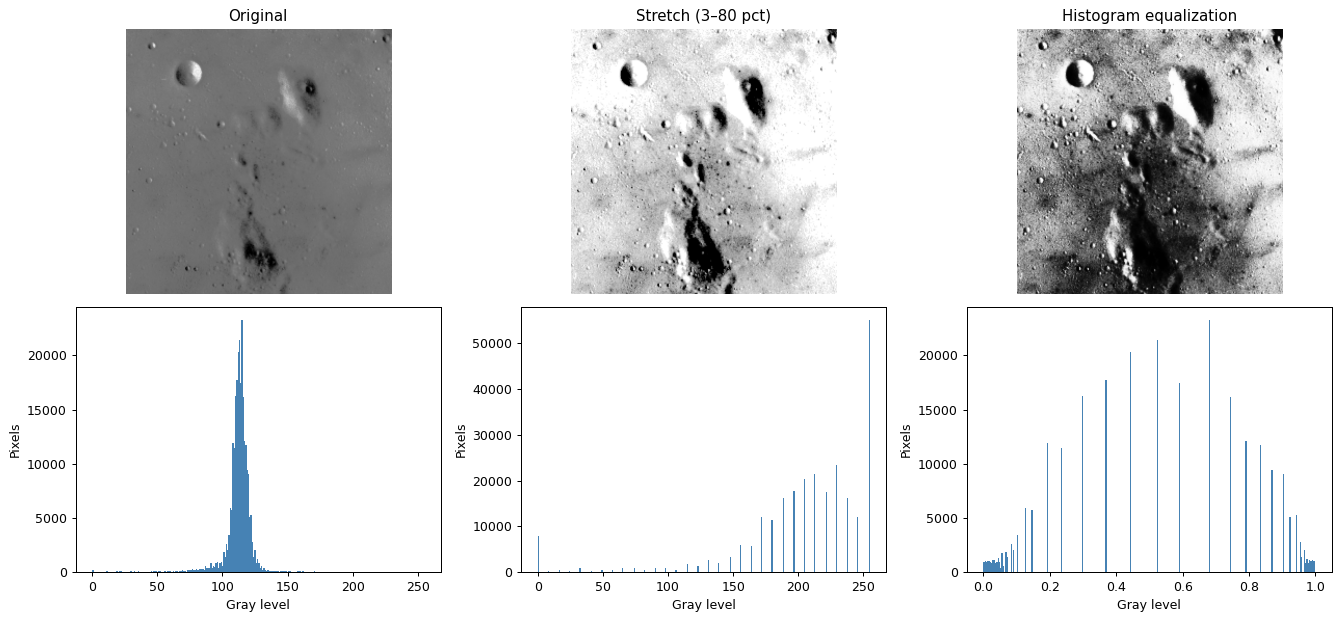

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for ax, im, t, hr in [
    (axes[0, 0], img,         'Original',                    (0, 255)),
    (axes[0, 1], img_rescale, 'Stretch (3–80 pct)',           (0, 255)),
    (axes[0, 2], img_eq,      'Histogram equalization',       (0, 1)),
]:
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')

for ax, im, hr in [
    (axes[1, 0], img,         (0, 255)),
    (axes[1, 1], img_rescale, (0, 255)),
    (axes[1, 2], img_eq,      (0, 1)),
]:
    ax.hist(im.flat, bins=256, range=hr, color='steelblue', edgecolor='none')
    ax.set_xlabel('Gray level'); ax.set_ylabel('Pixels')

plt.tight_layout()
plt.show()

**Comparison.** Three different histogram-shaping strategies, three different visual results:

| Method | What it does | Trade-off |
|---|---|---|
| Original | None | Low contrast, peak around the bright sky |
| Contrast stretch (3–80 pct) | Linear mapping of a percentile range to $[0, 255]$ | Aggressive but introduces clipping where the cut-off lands |
| Histogram equalization | Non-linear mapping using the CDF | Best overall contrast but can over-enhance noise in flat regions |

---

## Task #3 — Histogram matching

Histogram matching (a.k.a. histogram specification) generalizes equalization: instead of forcing the output to a *uniform* distribution, we force it to match the distribution of a **reference image** of our choice.

Given source $f$ and reference $r$, both with CDFs $C_f$ and $C_r$, the matching transformation is

$$T(v) = C_r^{-1}\!\big(C_f(v)\big)$$

so that the output's CDF approximates $C_r$.

In this task:
- **Source** image: `chelsea` (the cat) — its colour palette will be transformed.
- **Reference** image: `rocket` — its colour distribution is the target.

Both images are RGB, so we set `channel_axis=-1` to match each channel (R, G, B) independently.

In [21]:
# 1. Load source and reference images
source    = data.chelsea()     # source image — will be transformed
reference = data.rocket()      # reference image — target histogram

print(f"source (chelsea):   {source.shape}, dtype={source.dtype}")
print(f"reference (rocket): {reference.shape}, dtype={reference.dtype}")

# 2. Apply histogram matching, channel-by-channel for the RGB images
matched = exposure.match_histograms(source, reference, channel_axis=-1)
print(f"matched: shape={matched.shape}, dtype={matched.dtype}, "
      f"min/max={matched.min():.2f}/{matched.max():.2f}")

source (chelsea):   (300, 451, 3), dtype=uint8
reference (rocket): (427, 640, 3), dtype=uint8
matched: shape=(300, 451, 3), dtype=uint8, min/max=0.00/255.00


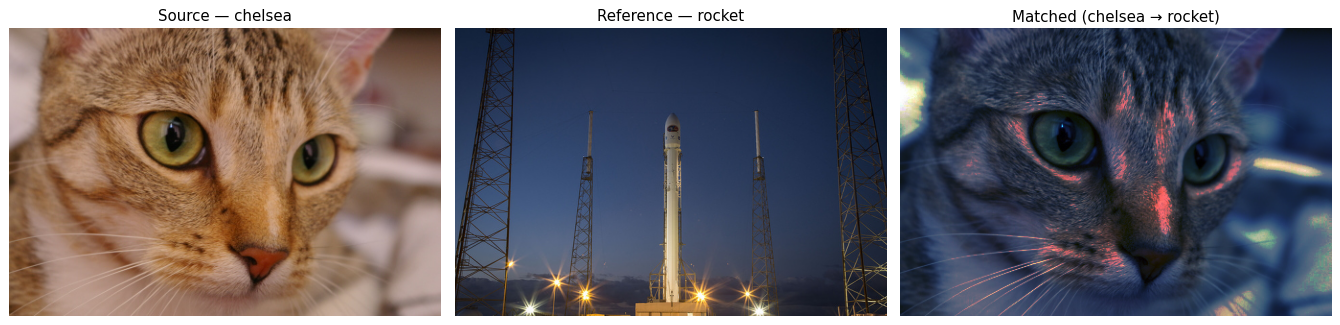

In [22]:
# Display the three images side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, im, title in [
    (axes[0], source,    'Source — chelsea'),
    (axes[1], reference, 'Reference — rocket'),
    (axes[2], matched,   'Matched (chelsea → rocket)'),
]:
    ax.imshow(im)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Per-channel histograms and CDFs

The clearest way to verify that the matching worked is to overlay the three images' **CDFs** for each colour channel. After matching, the source's CDF should track the reference's almost exactly.

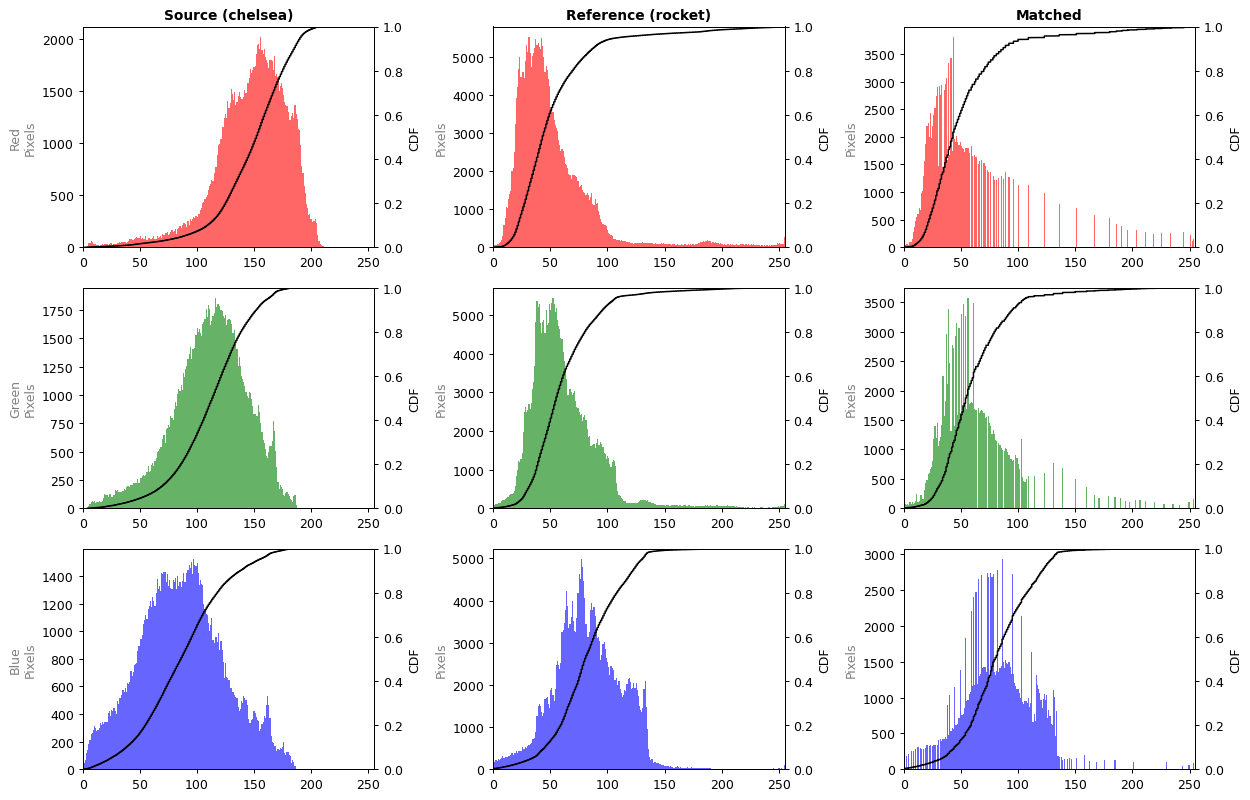

In [23]:
# Plot histogram and CDF for each RGB channel of all three images
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
channel_names = ['Red', 'Green', 'Blue']
images = [('Source (chelsea)', source),
          ('Reference (rocket)', reference),
          ('Matched', matched)]

for col, (label, im) in enumerate(images):
    for ch in range(3):
        ax = axes[ch, col]
        # Use raw values; matched is float — convert chelsea/rocket to float for fair comparison
        data_ch = im[..., ch].astype(np.float64).ravel()

        # Histogram (left axis)
        ax.hist(data_ch, bins=256, range=(0, 255),
                color=['red', 'green', 'blue'][ch], alpha=0.6)
        ax.set_xlim(0, 255)
        ax.set_ylabel('Pixels', color='gray')

        # CDF (right axis, normalized)
        ax2 = ax.twinx()
        sorted_vals = np.sort(data_ch)
        cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        ax2.plot(sorted_vals, cdf, color='black', linewidth=1.2)
        ax2.set_ylim(0, 1)
        ax2.set_ylabel('CDF', color='black')

        if ch == 0:
            ax.set_title(label, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{channel_names[ch]}\nPixels', color='gray')

plt.tight_layout()
plt.show()

**Observation.** The matched image's histograms (right column) closely mirror the reference image's histograms (middle column), channel by channel. The source's warm, indoor colour balance has been pushed toward the cooler, sky-dominated palette of the rocket image — most visibly, the cat's grey/brown fur shifts toward blue-tinted tones because the rocket reference is heavy in the blue channel.

The cat's *structure* (edges, texture, faces) is preserved — only the *intensity distribution* changes. This is exactly what histogram matching is designed to do: change tone/colour without altering content.

---

## Summary

| Task | Technique | Key skimage function |
|---|---|---|
| 1 | Percentile-based contrast stretching to $[p_3, p_{80}]$ | `exposure.rescale_intensity` |
| 2 | Histogram equalization (CDF mapping to uniform) | `exposure.equalize_hist` |
| 3 | Histogram matching (CDF mapping to reference) | `exposure.match_histograms` |

All three tasks belong to the family of **point operations** — each output pixel depends only on its input value and a global look-up table derived from the histogram. The progression is conceptually clean:

- **Stretching** uses a *linear* map between two chosen endpoints.
- **Equalization** uses a *non-linear* map (the CDF) to flatten the histogram.
- **Matching** uses a *non-linear* map (composition of two CDFs) to imitate any target distribution.

This is a useful mental model: every histogram-based contrast operation we'll meet in this course is just a different choice of mapping function applied via a 1-D look-up table.